In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import persim
from persim import PersistenceImager, PersLandscapeApprox, PersLandscapeExact
from persim.landscapes import plot_landscape_simple
import gudhi

# I - Exploratory Analysis of the Tumor Microenvironment

In this first part, we perform a descriptive analysis of two large hypoxic regions (LHR1 and LHR2) from head and neck squamous cell carcinoma specimens. The goal is to understand the spatial organization of immune cells (CD8, CD68, FoxP3) in relation to hypoxia, necrosis, and tumor architecture. We also provide a first qualitative look at topological features using persistence diagrams and their vectorizations. The two LHR are biologically similar.

In [89]:
LHR1 = pd.read_csv("LargeHypoxicRegion.csv")
LHR2 = pd.read_csv("LargeHypoxicRegion2.csv")

In [90]:
LHR1.head(5)

,x,y,PanCK+,CAIX+,Pimo+,Necrosis,Celltype
0,2.86,526.43,0,0,0,0,CD8
1,2.59,573.32,0,0,0,0,CD8
2,9.26,596.48,0,0,0,0,CD8
3,2.55,842.17,0,0,0,0,CD8
4,7.02,1044.55,0,0,0,0,CD8


In [91]:
LHR2.head(5)

,x,y,PanCK+,CAIX+,Pimo+,Necrosis,Celltype
0,2.59,67.20,0,0,0,0,CD8
1,7.99,106.15,0,1,0,0,CD8
2,3.25,373.03,0,0,0,0,CD8
3,8.40,480.41,0,0,0,0,CD8
4,3.93,572.57,0,0,0,0,CD8


In our dataset, we observe three types of immune cells:

- **CD8**: Their primary function is to identify and directly destroy infected or malignant cells. In the tumor microenvironment, a high spatial infiltration of CD8+ T cells within the tumor core is generally associated with a strong anti-tumor immune response and a better patient prognosis

- **CD68**: CD68 is a widely used pan-macrophage marker. These cells are specialized in phagocytosis (engulfing cellular debris and pathogens).

- **FoxP3**: Their primary role is to suppress immune responses and prevent autoimmunity. However, in cancer, a high infiltration of FoxP3 cells is generally a negative sign, as they actively inhibit the tumor-killing functions of the CD8 cells

## I.1 - Visualizing the distributions of cell types and hypoxic status

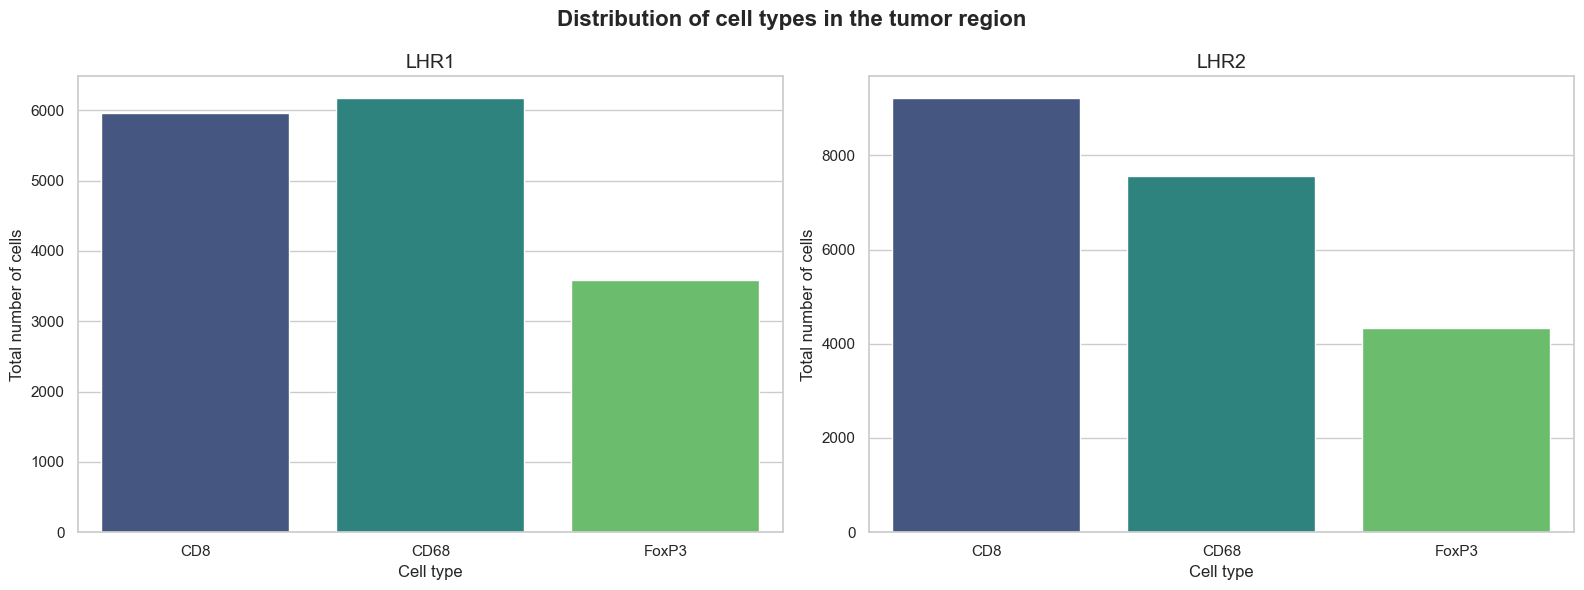

In [92]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of cell types in the tumor region', fontsize=16, fontweight='bold')

sns.countplot(data=LHR1, x='Celltype', hue='Celltype', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('LHR1', fontsize=14)
axes[0].set_xlabel('Cell type', fontsize=12)
axes[0].set_ylabel('Total number of cells', fontsize=12)

sns.countplot(data=LHR2, x='Celltype', hue='Celltype', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('LHR2', fontsize=14)
axes[1].set_xlabel('Cell type', fontsize=12)
axes[1].set_ylabel('Total number of cells', fontsize=12)

plt.tight_layout()

We observe a similar distribution across both regions: CD8 and CD68 cells are present in roughly equal numbers, while FoxP3 cells are approximately half as numerous. This suggests a balanced presence of cytotoxic (CD8) and phagocytic (CD68) immune cells in the tumor microenvironment, with a smaller but notable regulatory (FoxP3) population. The relatively low proportion of FoxP3 cells compared to CD8 cells could indicate that the anti-tumor immune response is not entirely suppressed in these regions.

Beyond cell type composition, a key factor shaping the tumor microenvironment is oxygen availability. We now investigate the hypoxic state of each cell using molecular markers present in our dataset.

**Hypoxia (Low Oxygen)**: Hypoxia refers to regions within the tissue that are deprived of adequate oxygen. As solid tumors grow rapidly, they often outstrip their local blood supply, creating these oxygen-starved areas. In cancer, hypoxia is a strong negative prognostic factor: it drives tumor aggressiveness, increases resistance to therapies (like radiation), and creates a highly immunosuppressive microenvironment that inhibits the function of CD8+ cells while promoting suppressive cells like FoxP3+.

**CAIX+ / Pimo+ (Hypoxia Markers)**: These are the specific markers used in the dataset to identify hypoxic cells. CAIX (Carbonic Anhydrase IX) is an endogenous protein produced by cells to survive low oxygen levels, while Pimo (Pimonidazole) is an exogenous chemical tracer that specifically binds to oxygen-deprived cells. In the following visualization, we use the CAIX+ marker to assess the hypoxic state of each cell type.

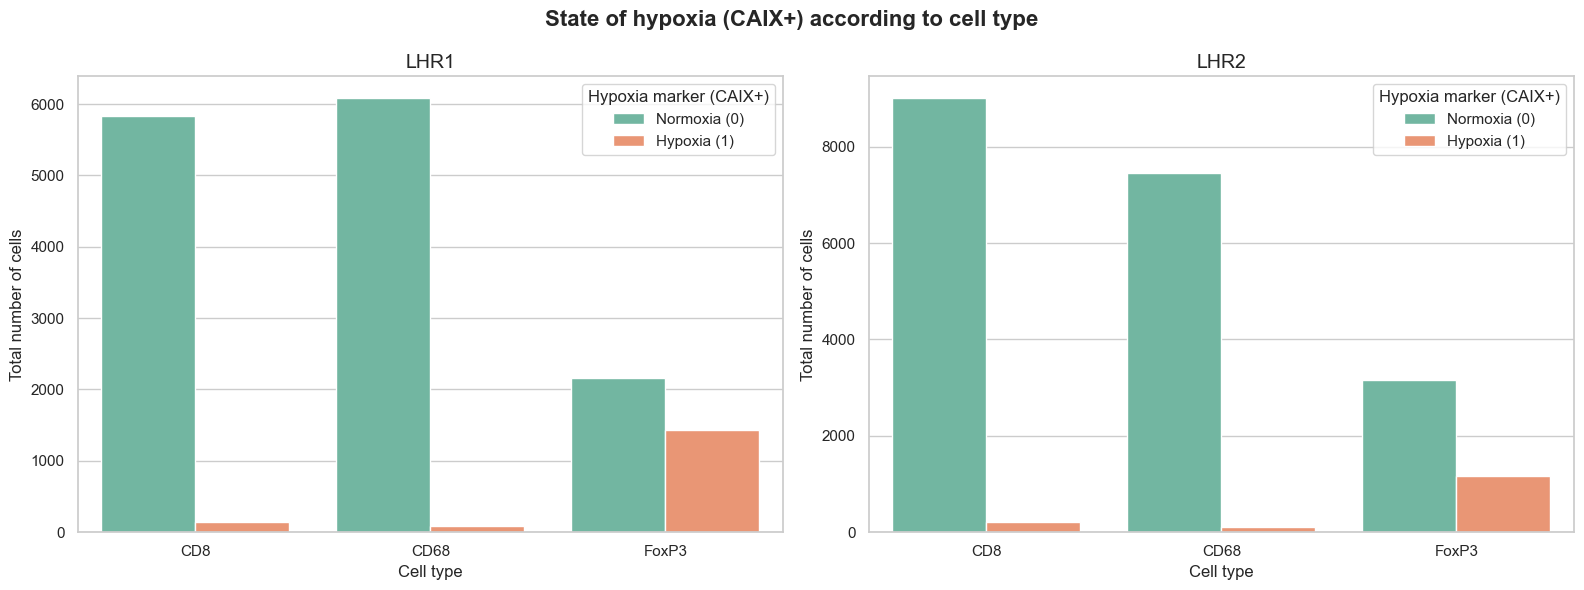

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('State of hypoxia (CAIX+) according to cell type', fontsize=16, fontweight='bold')

sns.countplot(data=LHR1, x='Celltype', hue='CAIX+', palette='Set2', ax=axes[0])
axes[0].set_title('LHR1', fontsize=14)
axes[0].set_xlabel('Cell type', fontsize=12)
axes[0].set_ylabel('Total number of cells', fontsize=12)
axes[0].legend(title='Hypoxia marker (CAIX+)', labels=['Normoxia (0)', 'Hypoxia (1)'])

sns.countplot(data=LHR2, x='Celltype', hue='CAIX+', palette='Set2', ax=axes[1])
axes[1].set_title('LHR2', fontsize=14)
axes[1].set_xlabel('Cell type', fontsize=12)
axes[1].set_ylabel('Total number of cells', fontsize=12)
axes[1].legend(title='Hypoxia marker (CAIX+)', labels=['Normoxia (0)', 'Hypoxia (1)'])

plt.tight_layout()

### Observations

**CD8 and CD68 — predominantly normoxic:** In both LHR1 and LHR2, the vast majority of CD8 (cytotoxic) and CD68 (macrophage) cells are in a normoxic state, with very few cells expressing the CAIX+ marker. This indicates that these immune populations reside mainly in well-oxygenated areas of the tumor.

**FoxP3 — a strong hypoxic signature:** In contrast, the FoxP3 (regulatory T-cell) population exhibits a significant proportion of hypoxic cells. This pattern is consistent across both regions, suggesting it is not an artifact but a genuine biological feature.

**Interpretation:** The co-localization of FoxP3 cells with hypoxic zones is consistent with the known biology of the tumor microenvironment: hypoxia promotes immunosuppression by recruiting and sustaining regulatory T-cells, while excluding cytotoxic CD8 cells. This reinforces the idea that oxygen-deprived regions act as immune-privileged niches where the tumor can evade the anti-tumor response.

## I.2 Visualizing the geographic repartition

In [94]:
df1 = LHR1.copy()
df2 = LHR2.copy()

for df in [df1, df2]:
    conditions = [
        (df['Necrosis'] == 1),
        (df['PanCK+'] == 1)
    ]
    choices = ['Necrotic Tissue', 'Tumor Cells (PanCK+)']
    df['Tissue_Structure'] = np.select(conditions, choices, default='Stroma / Immune')

fig, axes = plt.subplots(2, 3, figsize=(24, 18))
fig.suptitle('Spatial Distribution of Cells within the Tumor Microenvironment', fontsize=22, fontweight='bold')

for row, (df, label) in enumerate([(df1, 'LHR1'), (df2, 'LHR2')]):
    sns.scatterplot(
        data=df, x='x', y='y', hue='Celltype',
        palette={'CD8': '#3b528b', 'CD68': '#21918c', 'FoxP3': '#5ec962'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 0]
    )
    axes[row, 0].set_title(f'1. Immune Infiltration (Cell Types) — {label}', fontsize=16)
    axes[row, 0].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 0].set_ylabel('Y coordinate (µm)', fontsize=12)
    axes[row, 0].legend(title='Cell Type', markerscale=2)

    df_sorted_hypoxia = df.sort_values(by='CAIX+')
    sns.scatterplot(
        data=df_sorted_hypoxia, x='x', y='y', hue='CAIX+',
        palette={0: '#e0e0e0', 1: '#d62728'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 1]
    )
    axes[row, 1].set_title(f'2. Hypoxic Regions (CAIX+) — {label}', fontsize=16)
    axes[row, 1].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 1].set_ylabel('')
    axes[row, 1].legend(title='Hypoxia Status', labels=['Normoxia (0)', 'Hypoxia (1)'], markerscale=2)

    df_sorted_structure = df.sort_values(by='Tissue_Structure', ascending=False)
    sns.scatterplot(
        data=df_sorted_structure, x='x', y='y', hue='Tissue_Structure',
        palette={'Stroma / Immune': '#e0e0e0', 'Tumor Cells (PanCK+)': '#ff7f0e', 'Necrotic Tissue': '#000000'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 2]
    )
    axes[row, 2].set_title(f'3. Tumor Architecture & Necrosis — {label}', fontsize=16)
    axes[row, 2].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 2].set_ylabel('')
    axes[row, 2].legend(title='Tissue Component', markerscale=2)

plt.tight_layout(rect=[0, 0, 1, 0.96])

Error in callback <function flush_figures at 0x11840f6a0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

### Observations

**Immune infiltration (panel 1):** CD8, CD68 and FoxP3 cells are spread across the tissue but tend to concentrate at the periphery of the tumor mass rather than within its core. This pattern of immune exclusion is a hallmark of aggressive solid tumors.

**Hypoxic regions (panel 2):** The CAIX+ hypoxic cells (red) form well-defined clusters that are not randomly distributed. They are primarily located around the necrotic cores, forming a gradient of decreasing oxygen from the tumor periphery inward.

**Tumor architecture (panel 3):** The necrotic tissue (black) sits at the center of the tumor mass (orange/PanCK+), surrounded by the hypoxic belt observed in panel 2. The stroma and immune cells (grey) populate the outer margins.

**Cross-panel interpretation:** These three views reveal a concentric spatial organization: a necrotic core, surrounded by a hypoxic ring rich in FoxP3 cells, and an oxygenated periphery where CD8 and CD68 cells are more prevalent. This architecture shows how the tumor's physical structure and metabolic environment shape immune cell distribution, effectively creating a barrier that shields the tumor interior from immune attack. This pattern is consistent across both LHR1 and LHR2.

## I.3 - Topological Data Analysis (TDA)

The previous visualizations gave us a qualitative understanding of the spatial organization. We now turn to **Topological Data Analysis** to quantify these spatial patterns rigorously.

The idea is to study the **shape** of the point clouds formed by each cell type using persistent homology. In the code below, we compute persistence from a 2D **Alpha complex** built on the observed cell coordinates, and track the appearance and disappearance of topological features across scales:

- **$H_0$ (connected components):** Points start as isolated components that merge as the scale increases. Features that persist over a long range indicate well-separated clusters, while short-lived features reflect dense, uniformly distributed cells.
- **$H_1$ (loops/holes):** These capture circular voids in the point cloud. A persistent loop suggests a ring-like arrangement of cells surrounding an empty region — potentially a hole in the immune infiltration pattern (e.g., around a necrotic or hypoxic zone).

### I.3.a - Plotting the persistence diagrams

Calculating CD8 LHR1: 1500 points...
Calculating CD8 LHR2: 1500 points...
Calculating CD68 LHR1: 1500 points...
Calculating CD68 LHR2: 1500 points...
Calculating FoxP3 LHR1: 1500 points...
Calculating FoxP3 LHR2: 1500 points...


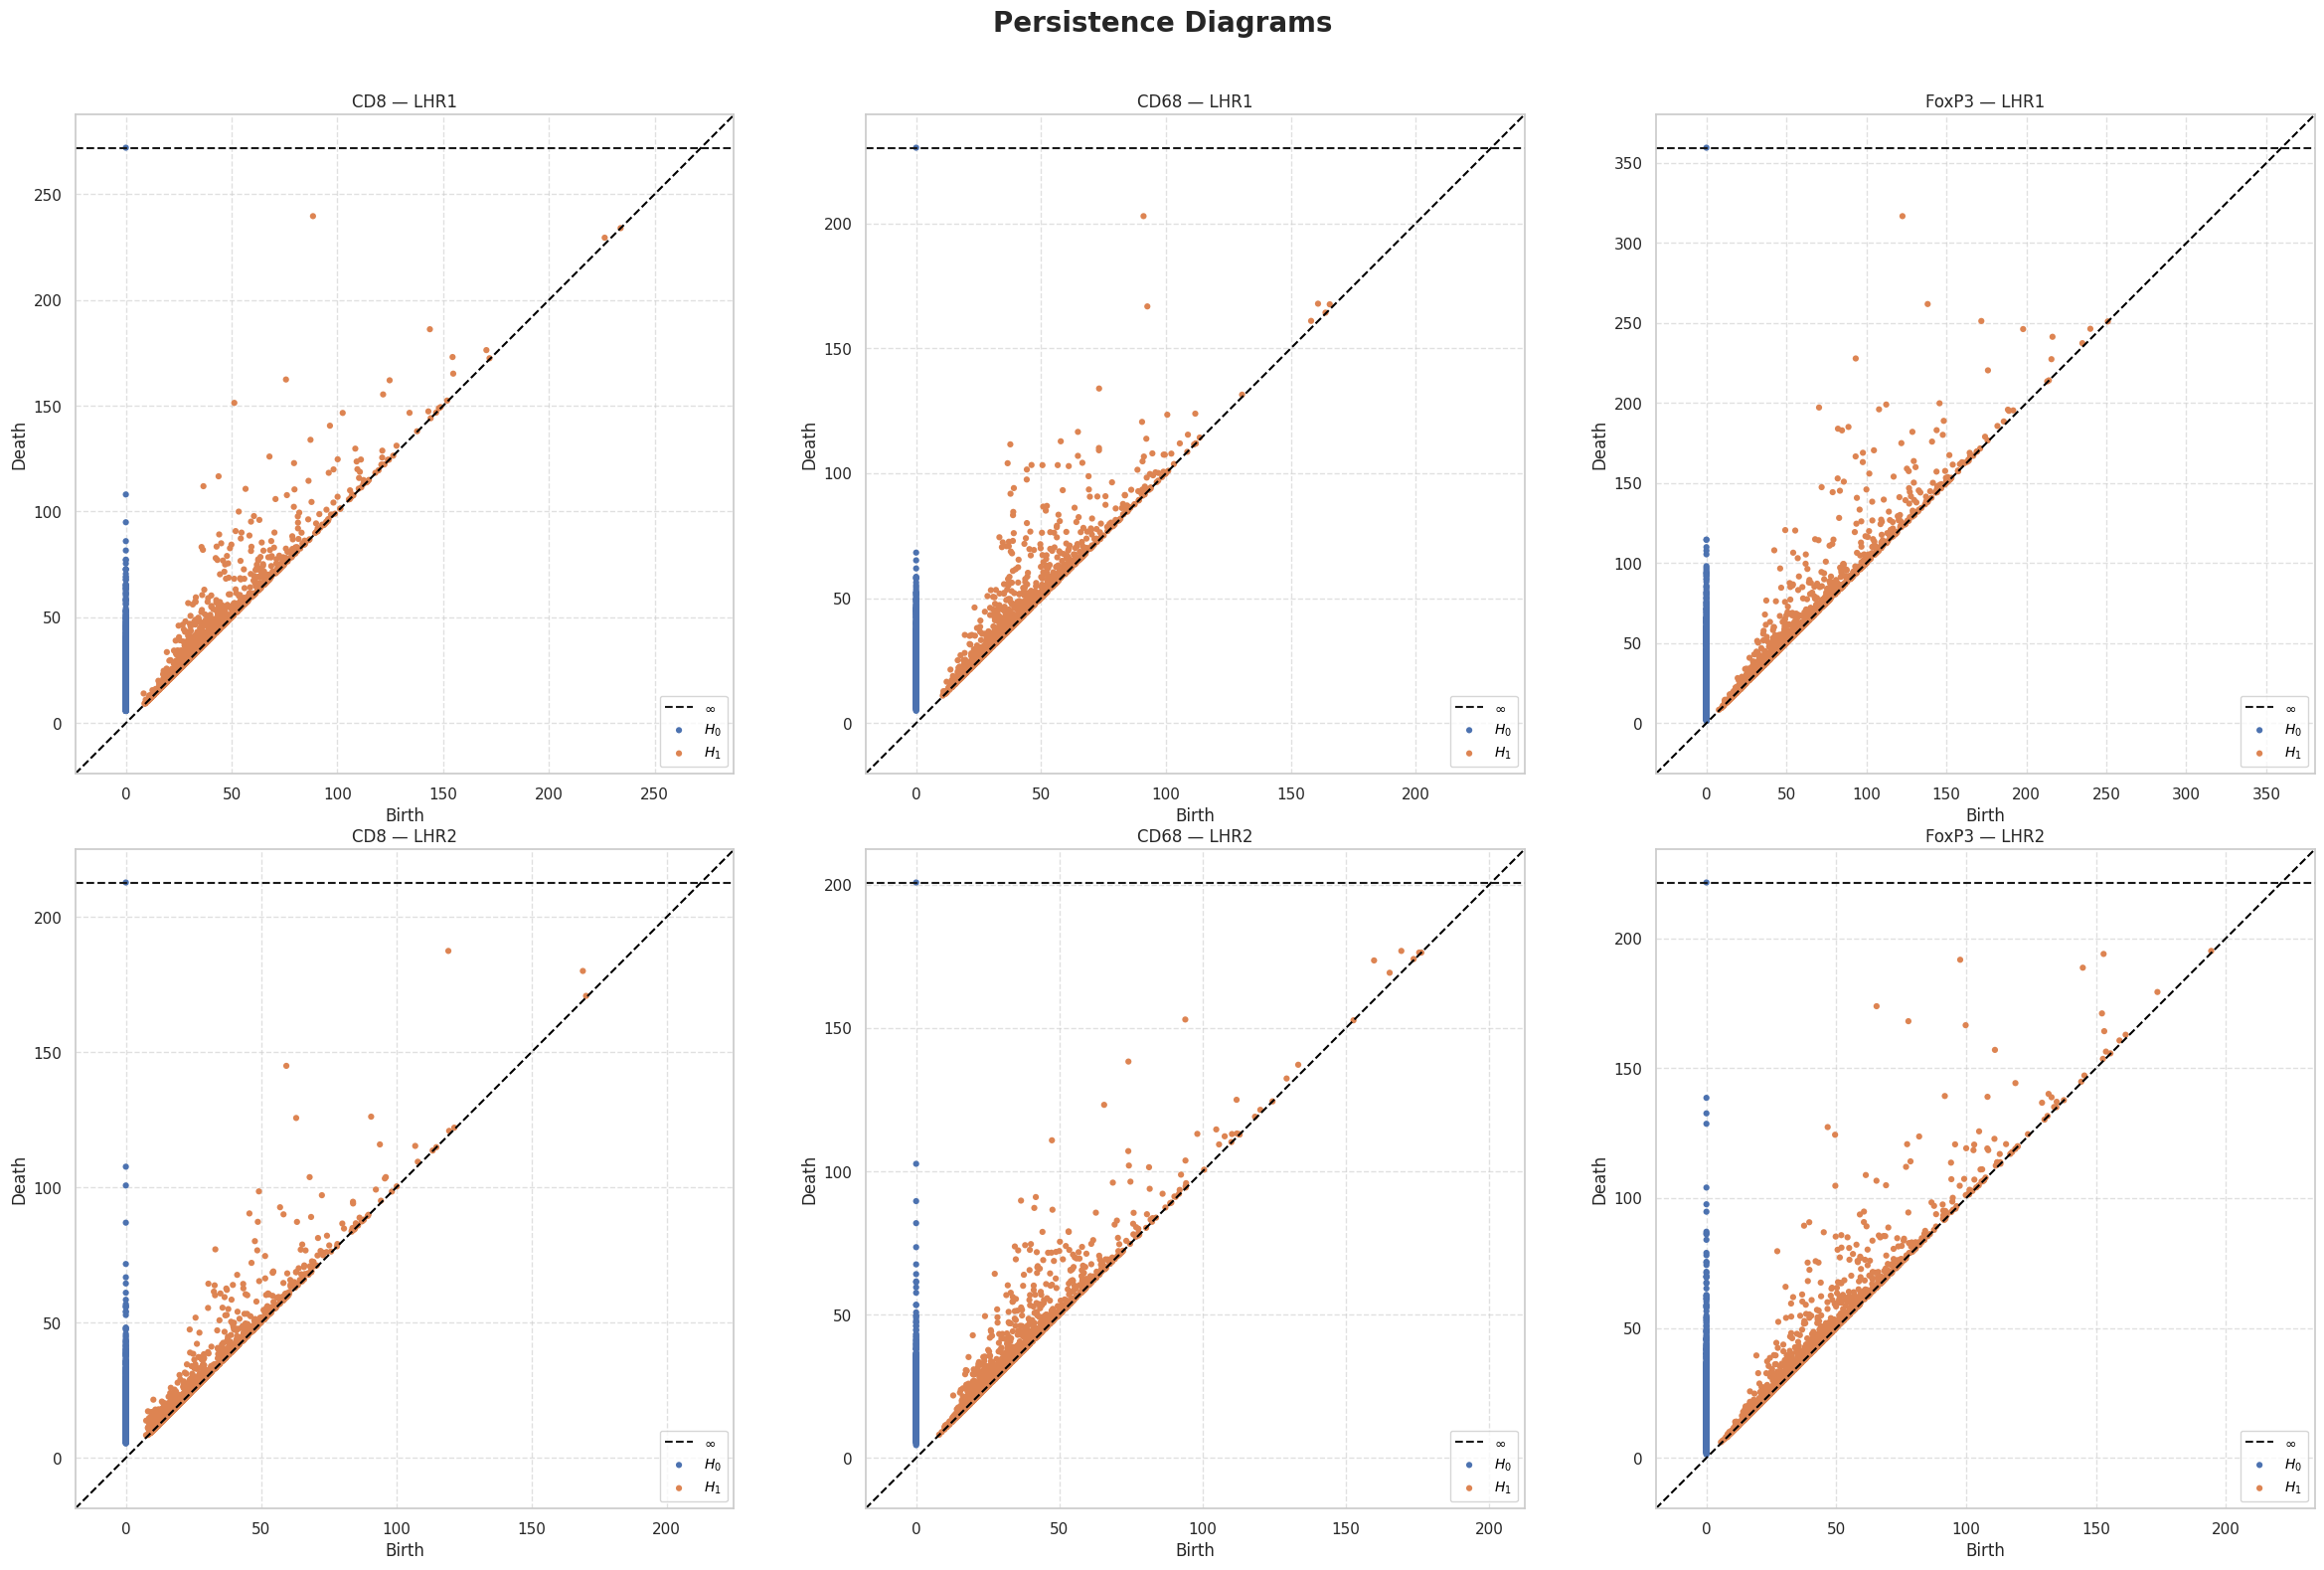

In [ ]:
datasets = {
    'CD8': {'LHR1': LHR1, 'LHR2': LHR2},
    'CD68': {'LHR1': LHR1, 'LHR2': LHR2},
    'FoxP3': {'LHR1': LHR1, 'LHR2': LHR2},
}

all_diagrams = {}
for celltype in ['CD8', 'CD68', 'FoxP3']:
    for label, df in [('LHR1', LHR1), ('LHR2', LHR2)]:
        data = df[df['Celltype'] == celltype][['x', 'y']].values
        data = data[:1500]

        print(f"Calculating {celltype} {label}: {len(data)} points...")
        alpha = gudhi.AlphaComplex(points=data)
        simplex_tree = alpha.create_simplex_tree()
        simplex_tree.compute_persistence()

        # Extract diagrams in the same format
        diagrams_h0 = np.sqrt(simplex_tree.persistence_intervals_in_dimension(0))
        diagrams_h1 = np.sqrt(simplex_tree.persistence_intervals_in_dimension(1))
        all_diagrams[(celltype, label)] = [diagrams_h0,diagrams_h1]

# Store in named variables for downstream cells
diagrams_CD8_1 = all_diagrams[('CD8', 'LHR1')]
diagrams_CD68_1 = all_diagrams[('CD68', 'LHR1')]
diagrams_Fox_1 = all_diagrams[('FoxP3', 'LHR1')]
diagrams_CD8_2 = all_diagrams[('CD8', 'LHR2')]
diagrams_CD68_2 = all_diagrams[('CD68', 'LHR2')]
diagrams_Fox_2 = all_diagrams[('FoxP3', 'LHR2')]

# Plotting the results
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Persistence Diagrams', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]

        # Persim function to easily plot the diagrams
        persim.plot_diagrams(all_diagrams[(celltype, label)], show=False,
                             title=f"{celltype} — {label}",
                             labels=['$H_0$', '$H_1$'], ax=ax)
        ax.set_xlabel("Birth", fontsize=12)
        ax.set_ylabel("Death", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])

### Observations

**$H_0$ — connectivity:** Across all cell types and both regions, the $H_0$ points cluster near the diagonal, meaning connected components merge quickly as the scale grows. This confirms that the immune cells form a single, densely connected spatial distribution rather than isolated clusters.

**$H_1$ — loops in CD8 and CD68:** Both CD8 and CD68 diagrams exhibit numerous $H_1$ features, many with moderate to high persistence (far from the diagonal). This indicates the presence of significant circular voids in their spatial distribution — consistent with the immune exclusion zones observed in the spatial maps (areas around necrotic/hypoxic cores where these cells are absent).

**$H_1$ — loops in FoxP3:** The FoxP3 diagrams show fewer and generally less persistent $H_1$ features. This is expected since FoxP3 cells, being co-localized with hypoxic zones, fill in some of the voids that CD8 and CD68 cells avoid. Their spatial distribution is more homogeneous, with fewer "holes".

### I.3.b - Plotting the corresponding vectorisation

To move from visual inspection to quantitative comparison, we transform the persistence diagrams into fixed-size vector representations:

- **Persistence Images:** Each diagram is converted into a 2D image by placing a Gaussian kernel on each point in the birth-persistence plane. This produces a stable, differentiable summary that can be used as input for machine learning models or statistical tests. Bright regions indicate where topological features concentrate.

- **Persistence Landscapes:** Each diagram is converted into a sequence of piecewise-linear functions (one per "depth level"). The first landscape captures the most persistent features, the second captures the next most persistent, etc. Landscapes live in a Banach space, which allows computing means, norms, and statistical tests directly.

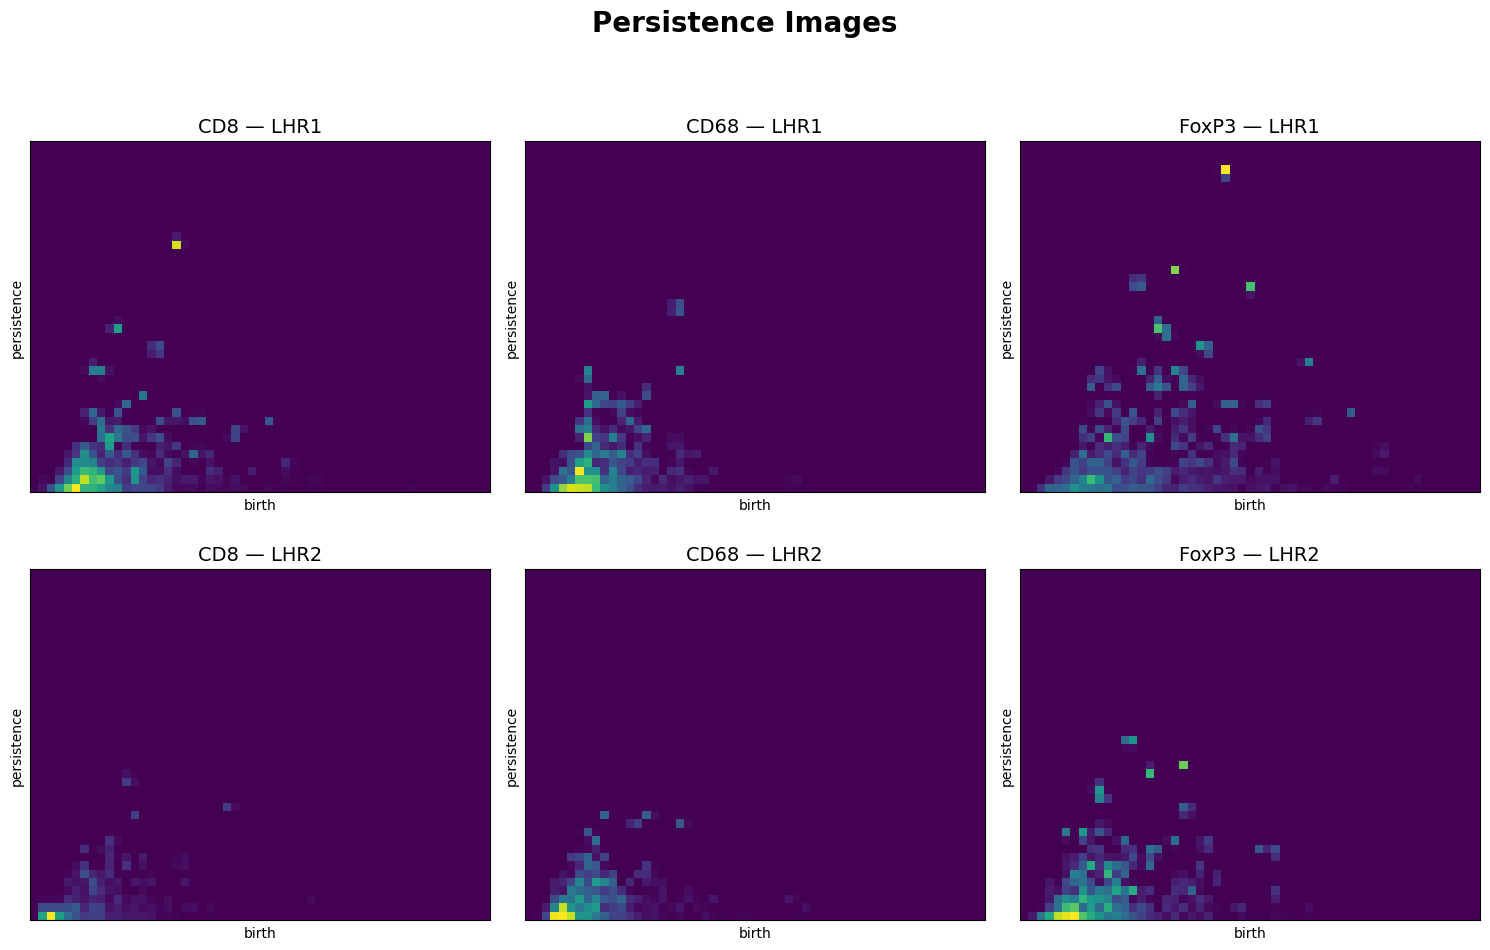

In [ ]:
all_diagrams_list = [diagrams_CD8_1, diagrams_CD68_1, diagrams_Fox_1, diagrams_CD8_2, diagrams_CD68_2, diagrams_Fox_2]

all_births = [np.max(d[1][:, 0]) for d in all_diagrams_list if d[1].size > 0]
all_pers = [np.max(d[1][:, 1] - d[1][:, 0]) for d in all_diagrams_list if d[1].size > 0]
global_max_birth = max(all_births)
global_max_pers = max(all_pers)

pimgr = PersistenceImager(
    pixel_size=global_max_birth / 50,
    birth_range=(0, global_max_birth * 1.1),
    pers_range=(0, global_max_pers * 1.1),
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Persistence Images', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]
        dgm = all_diagrams_list[row * 3 + col]
        img = pimgr.transform(dgm[1])
        pimgr.plot_image(img, ax=ax)
        ax.set_title(f"{celltype} — {label}", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])

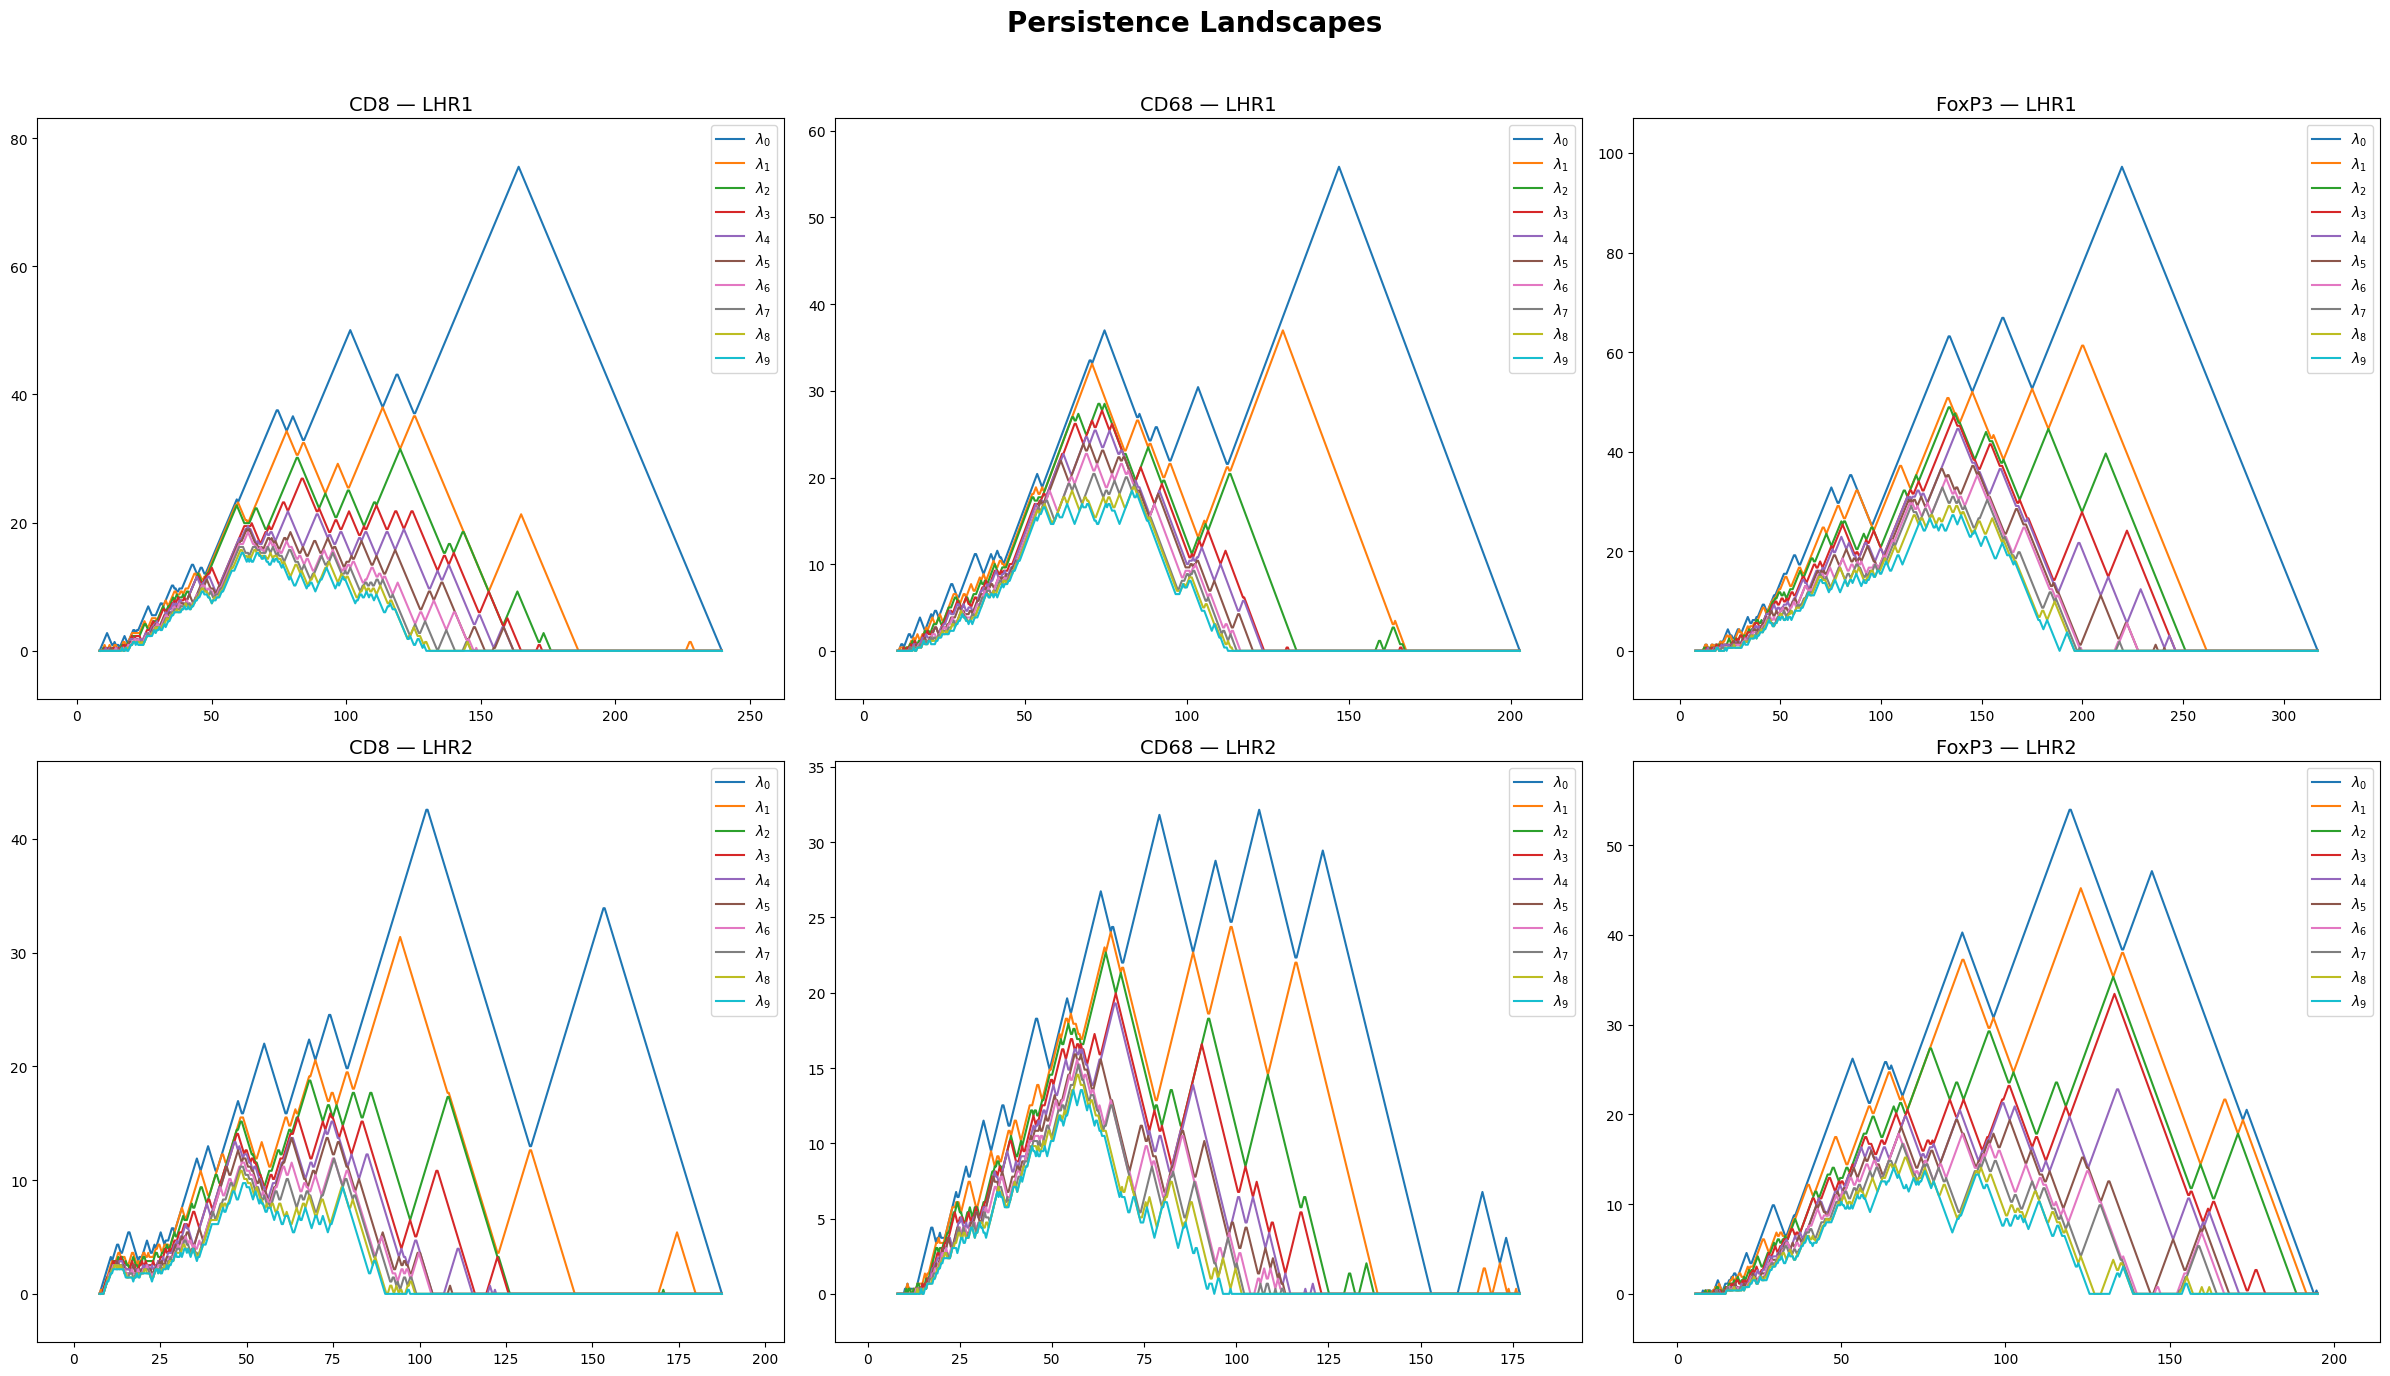

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Persistence Landscapes', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']
diagrams_map = {
    ('CD8', 'LHR1'): diagrams_CD8_1, ('CD68', 'LHR1'): diagrams_CD68_1, ('FoxP3', 'LHR1'): diagrams_Fox_1,
    ('CD8', 'LHR2'): diagrams_CD8_2, ('CD68', 'LHR2'): diagrams_CD68_2, ('FoxP3', 'LHR2'): diagrams_Fox_2,
}

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]
        pla = PersLandscapeApprox(dgms=diagrams_map[(celltype, label)], hom_deg=1)
        plot_landscape_simple(pla, depth_range=range(10), ax=ax)
        ax.set_title(f"{celltype} — {label}", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# II — TDA-Based Classification of Immune Cell Spatial Patterns

In Part I, we observed qualitative differences in how CD8, CD68 and FoxP3 cells organize spatially within the tumor. We now ask: **can we automatically distinguish immune cell types based solely on the topology of their spatial distribution?**

To answer this, we use the dataset of **1.5mm x 1.5mm tumor regions** from Vipond et al. (2021), which contains ~535 regions per cell type across multiple tumors. For each region, we:

1. **Compute persistent homology**
2. **Store the $H_0$ and $H_1$ persistence diagrams**
3. **Convert the diagrams into one-parameter persistence landscapes**
4. **Classify** cell types with ML algorithms under grouped tumor-level splits

This part is therefore fully based on the **one-parameter landscape pipeline** used throughout the rest of the notebook.

## II.1 - Loading the 1.5mm Regions dataset

The dataset comes from Vipond et al. (2021) and consists of immunohistochemistry (IHC) images of head and neck squamous cell carcinoma specimens, segmented into non-overlapping **1.5mm x 1.5mm** regions of interest (ROIs).

Each CSV file contains the **(x, y) coordinates** of all cells of a single type detected in one ROI. There is no hypoxia marker here — just spatial positions. The data spans **~12 different tumors** (T_A through T_P), with multiple ROIs per tumor.

We recover the **tumor identifier** directly from the filename and keep it throughout the pipeline. This allows us to evaluate the classifiers with **grouped train/test splits at the tumor level**, rather than mixing ROIs from the same tumor across train and test.

We also filter out regions with fewer than 20 cells, as these are too sparse to produce meaningful topological features.

In [ ]:
import os
import glob
from pathlib import Path

base_path = "1.5mmRegions"
celltypes = ['CD8', 'FoxP3', 'CD68']
GLOBAL_SEED = 42
rng_global = np.random.default_rng(GLOBAL_SEED)


def extract_tumor_id(filepath):
    # Extract the tumor identifier from filenames such as T_I_ROI_12_locations_CD8.csv
    return Path(filepath).name.split('_ROI_')[0]


regions = {}
for ct in celltypes:
    folder = os.path.join(base_path, ct)
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    regions[ct] = []
    for f in files:
        df = pd.read_csv(f)
        if len(df) >= 20:
            regions[ct].append({
                'points': df[['x', 'y']].values,
                'tumor_id': extract_tumor_id(f),
                'filename': Path(f).name,
            })

for ct in celltypes:
    # Checking the number of regions in each cell type
    tumor_ids = sorted({region['tumor_id'] for region in regions[ct]})
    print(f"{ct}: {len(regions[ct])} regions loaded across {len(tumor_ids)} tumors")

CD8: 530 regions loaded across 16 tumors
FoxP3: 502 regions loaded across 16 tumors
CD68: 549 regions loaded across 16 tumors


## II.2 - Computing persistence diagrams for all regions

For each region, we compute **persistent homology up to dimension 1** using a 2D **Alpha complex** implemented in `gudhi`. This means we track:
- **$H_0$**: how connected components merge as the scale parameter grows
- **$H_1$**: how loops (circular voids) appear and disappear

The output is a **persistence diagram**: a set of (birth, death) pairs, where each pair represents a topological feature that appears at the "birth" scale and disappears at the "death" scale. A point far from the diagonal corresponds to a **persistent** feature, while a point near the diagonal is often interpreted as topological noise.

In the current notebook, after filtering out very sparse regions, we do **not** apply any additional subsampling: each ROI is processed using all available points. We keep the ROI metadata together with the resulting $H_0$ and $H_1$ diagrams for downstream vectorization and classification.

In [ ]:
# Function to use to reduce the number of points if there are too many
def subsample_points(pts, max_points, seed_offset=0):
    #Subsample a point cloud reproducibly when it exceeds max_points.
    if len(pts) <= max_points:
        return pts.copy()
    rng_local = np.random.default_rng(GLOBAL_SEED + seed_offset)
    idx = rng_local.choice(len(pts), max_points, replace=False)
    return pts[idx]


diagrams_by_type = {}
region_metadata = []
for ct in celltypes:
    diagrams_by_type[ct] = []
    for i, region in enumerate(regions[ct]):
        #pts_sub = subsample_points(region['points'], MAX_POINTS, seed_offset=i)

        pts_sub = region['points']
        #Computing persistence
        alpha = gudhi.AlphaComplex(points=pts_sub)
        simplex_tree = alpha.create_simplex_tree()
        simplex_tree.compute_persistence()
        # Extract diagrams and convert squared filtration values to actual distances
        diagrams_h0 = np.sqrt(simplex_tree.persistence_intervals_in_dimension(0))
        diagrams_h1 = np.sqrt(simplex_tree.persistence_intervals_in_dimension(1))

        diagrams_by_type[ct].append([diagrams_h0,diagrams_h1])
        region_metadata.append({
            'celltype': ct,
            'tumor_id': region['tumor_id'],
            'filename': region['filename'],
            'n_points_original': len(region['points']),
            'n_points_used': len(pts_sub),
        })
        if (i + 1) % 100 == 0:
            print(f"  {ct}: {i + 1}/{len(regions[ct])} done")
    print(f"{ct}: {len(diagrams_by_type[ct])} diagrams computed")

  CD8: 100/530 done
  CD8: 200/530 done
  CD8: 300/530 done
  CD8: 400/530 done
  CD8: 500/530 done
CD8: 530 diagrams computed
  FoxP3: 100/502 done
  FoxP3: 200/502 done
  FoxP3: 300/502 done
  FoxP3: 400/502 done
  FoxP3: 500/502 done
FoxP3: 502 diagrams computed
  CD68: 100/549 done
  CD68: 200/549 done
  CD68: 300/549 done
  CD68: 400/549 done
  CD68: 500/549 done
CD68: 549 diagrams computed


## II.3 - Assembling ROI-level records



At this stage we only assemble, for each ROI:
- its metadata (`celltype`, `tumor_id`, `filename`)
- the raw point cloud
- the finite $H_0$ persistence pairs
- the $H_1$ persistence pairs

The actual vectorization is done later inside the landscape pipeline. Keeping the raw diagrams separate from the classifier makes it easier to avoid train/test leakage and to swap representations cleanly.

This outputs y, groups, and roi_records: y are the classes, groups are the identifier corresponding to the tumor for group cross validation, roi_records contains the raw_points, h0 and h1 diagrams


In [ ]:
def finite_h0(dgm):
    #Remove the single infinite H0 point before vectorization
    return dgm[0][np.isfinite(dgm[0][:, 1])]

def build_roi_records(regions_by_type, diagrams_lookup):
    records = []
    for ct in celltypes:
        for region, dgm in zip(regions_by_type[ct], diagrams_lookup[ct]):
            records.append({
                'celltype': ct,
                'tumor_id': region['tumor_id'],
                'filename': region['filename'],
                'points': region['points'],
                'diagram_h0': np.array(finite_h0(dgm)),
                'diagram_h1': np.array(dgm[1]),
            })
    return records


roi_records = build_roi_records(regions, diagrams_by_type)

y = np.array([record['celltype'] for record in roi_records])
groups = np.array([record['tumor_id'] for record in roi_records])
filenames = np.array([record['filename'] for record in roi_records])

## II.4 Classification with one-parameter persistence landscapes

To follow more closely the methodology of Vipond et al. (2021) while remaining in **one-parameter persistent homology**, we use **persistence landscapes** built from the ROI-level persistence diagrams.

Our baseline uses:
- the **first $H_1$ persistence landscape** only
- a **regularized LDA classifier** on the resulting landscape vectors

### What is the landscape grid?
A persistence landscape is a function of the filtration parameter. To feed it into a classifier, we sample that function on a finite grid of values.

In practice, the notebook uses `Landscape(num_landscapes=10, resolution=80)`, fitted on the **training diagrams only** within each fold. This means that the representation is always learned from the training tumors and then applied to the held-out tumors, which avoids leakage from test data into the feature construction.

### Why this section can be slow
There are two expensive parts in the notebook:
1. computing diagrams
2. repeating grouped train/test evaluation many times

The Alpha-complex computation is the true bottleneck: its cost grows quickly with the number of points, although it is far better than Rips-complex ($O(nlog(n))$ vs $O(n^3)$).

The landscape vectorization itself is much lighter than the diagram computation, but it still has to be repeated fold by fold because it is always fitted on the training set only.

**Evaluation protocol:** For each task, we use grouped cross-validation at the tumor level with `StratifiedGroupKFold`. All ROIs from a tumor stay entirely in either the training fold or the test fold, so evaluation is always performed on **unseen tumors**.

In practice, the number of folds is set to `min(10, number of tumors in the task)`, which yields up to 10 tumor-level folds depending on the subset being evaluated.

We test 4 tasks:
- 3 **pairwise** comparisons: CD8 vs FoxP3, CD8 vs CD68, FoxP3 vs CD68
- 1 **three-way** classification: CD8 vs FoxP3 vs CD68

A random baseline would give **50%** for pairwise and **33%** for three-way (approximatively, since the numbers of cell-types are roughly of the same order in the dataset). Because the split is done at the tumor level, these accuracies target generalization to **unseen tumors** rather than to unseen ROIs from already-seen tumors, which is important to avoid data leakage.

We use **accuracy** as the main metric. Since the three classes are of broadly comparable size, it provides a readable first summary of performance across tasks.


In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations
from numpy.linalg import LinAlgError
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedGroupKFold
from gudhi.representations import Landscape

N_SPLITS        = 10
LANDSCAPE_STEPS = 80

tasks = list(combinations(celltypes, 2)) + [tuple(celltypes)]
rows  = []

X_h0     = np.array([r['diagram_h0'] for r in roi_records], dtype=object)
X_h1     = np.array([r['diagram_h1'] for r in roi_records], dtype=object)
y_all    = np.array([r['celltype']   for r in roi_records])
grp_all  = np.array([r['tumor_id']   for r in roi_records])

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    X_task   = X_h1[mask]
    y_task   = y_all[mask]
    grp_task = grp_all[mask]

    cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))))
    scores = []

    for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
        y_train, y_test = y_task[train_idx], y_task[test_idx]

        pipe = Pipeline([
            ('landscape', Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)),
            ('scaler',    StandardScaler()),
            ('clf',       LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
        ])

        try:
            pipe.fit(X_task[train_idx], y_train)
            scores.append(pipe.score(X_task[test_idx], y_test))
        except (LinAlgError, ValueError):
            continue

    rows.append({
        'Task'         : task_label,
        'Mean accuracy': np.mean(scores) if scores else np.nan,
        'Std'          : np.std(scores)  if scores else np.nan,
    })

df_results = pd.DataFrame(rows).set_index('Task')
df_results = df_results.style.format({
    'Mean accuracy': '{:.1%}',
    'Std'          : '{:.1%}',
}).set_caption('LDA - H1 Only')
df_results

,Mean accuracy,Std
Task,,
CD8 vs FoxP3,71.6%,11.8%
CD8 vs CD68,63.1%,9.7%
FoxP3 vs CD68,75.6%,11.1%
3-way,56.2%,9.1%


In [ ]:
rows  = []

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    X_task   = X_h0[mask]
    y_task   = y_all[mask]
    grp_task = grp_all[mask]

    cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))))
    scores = []

    for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
        y_train, y_test = y_task[train_idx], y_task[test_idx]

        pipe = Pipeline([
            ('landscape', Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)),
            ('scaler',    StandardScaler()),
            ('clf',       LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
        ])

        try:
            pipe.fit(X_task[train_idx], y_train)
            scores.append(pipe.score(X_task[test_idx], y_test))
        except (LinAlgError, ValueError):
            continue

    rows.append({
        'Task'         : task_label,
        'Mean accuracy': np.mean(scores) if scores else np.nan,
        'Std'          : np.std(scores)  if scores else np.nan,
    })

df_results = pd.DataFrame(rows).set_index('Task')
df_results = df_results.style.format({
    'Mean accuracy': '{:.1%}',
    'Std'          : '{:.1%}',
}).set_caption('LDA - H0 Only')
df_results

,Mean accuracy,Std
Task,,
CD8 vs FoxP3,62.3%,15.0%
CD8 vs CD68,61.8%,8.9%
FoxP3 vs CD68,68.3%,15.9%
3-way,52.3%,11.0%


In [ ]:
rows = []

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    X_h0_task = X_h0[mask]
    X_h1_task = X_h1[mask]
    y_task   = y_all[mask]
    grp_task = grp_all[mask]

    cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))))
    scores = []

    for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
        y_train, y_test = y_task[train_idx], y_task[test_idx]

        ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
        ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

        X_train = np.hstack([
            ls_h0.fit_transform(X_h0_task[train_idx]),
            ls_h1.fit_transform(X_h1_task[train_idx]),
        ])
        X_test = np.hstack([
            ls_h0.transform(X_h0_task[test_idx]),
            ls_h1.transform(X_h1_task[test_idx]),
        ])

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
        ])

        try:
            pipe.fit(X_train, y_train)
            scores.append(pipe.score(X_test, y_test))
        except (LinAlgError, ValueError):
            continue

    rows.append({
        'Task'         : task_label,
        'Mean accuracy': np.mean(scores) if scores else np.nan,
        'Std'          : np.std(scores)  if scores else np.nan,
    })

pd.DataFrame(rows).set_index('Task').style.format({
    'Mean accuracy': '{:.1%}',
    'Std'          : '{:.1%}',
}).set_caption('LDA - H0 + H1')

,Mean accuracy,Std
Task,,
CD8 vs FoxP3,70.3%,11.9%
CD8 vs CD68,63.2%,8.7%
FoxP3 vs CD68,72.2%,13.8%
3-way,56.0%,8.2%


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

models = {'LogReg' : LogisticRegression(max_iter=1000),
          'Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3)}

for model in models:
    rows = []

    for task in tasks:
        task_label = " vs ".join(task) if len(task) == 2 else "3-way"
        mask     = np.isin(y_all, list(task))
        X_h0_task = X_h0[mask]
        X_h1_task = X_h1[mask]
        y_task   = y_all[mask]
        grp_task = grp_all[mask]

        cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))))
        scores = []

        for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
            y_train, y_test = y_task[train_idx], y_task[test_idx]

            ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
            ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

            X_train = np.hstack([
                ls_h0.fit_transform(X_h0_task[train_idx]),
                ls_h1.fit_transform(X_h1_task[train_idx]),
            ])
            X_test = np.hstack([
                ls_h0.transform(X_h0_task[test_idx]),
                ls_h1.transform(X_h1_task[test_idx]),
            ])

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('clf',    models[model]),
            ])

            try:
                pipe.fit(X_train, y_train)
                scores.append(pipe.score(X_test, y_test))
            except (LinAlgError, ValueError):
                continue

        rows.append({
            'Task'         : task_label,
            'Mean accuracy': np.mean(scores) if scores else np.nan,
            'Std'          : np.std(scores)  if scores else np.nan,
        })

    df_results = pd.DataFrame(rows)
    df_results = df_results.set_index('Task').style.format({
        'Mean accuracy': '{:.1%}',
        'Std'          : '{:.1%}',
    }).set_caption(model)
    display(df_results)

,Mean accuracy,Std
Task,,
CD8 vs FoxP3,70.7%,9.8%
CD8 vs CD68,62.3%,7.8%
FoxP3 vs CD68,70.7%,13.0%
3-way,53.1%,7.1%


,Mean accuracy,Std
Task,,
CD8 vs FoxP3,78.5%,8.8%
CD8 vs CD68,65.8%,7.9%
FoxP3 vs CD68,76.7%,12.1%
3-way,60.7%,7.5%


## II.6 - Confusion matrix (regularized LDA, 3-way)

To better understand the classification errors, we display the **confusion matrix** of the regularized LDA classifier on the 3-way task. Each row represents the true label and each column the predicted label.

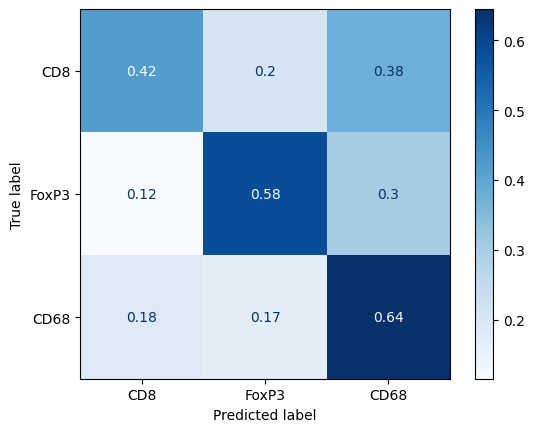

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

three_way_task = tuple(celltypes)
mask     = np.isin(y_all, list(three_way_task))
X_h0_task = X_h0[mask]
X_h1_task = X_h1[mask]
y_task   = y_all[mask]
grp_task = grp_all[mask]

cv = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))))
y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
    y_train, y_test = y_task[train_idx], y_task[test_idx]

    ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
    ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

    X_train = np.hstack([
        ls_h0.fit_transform(X_h0_task[train_idx]),
        ls_h1.fit_transform(X_h1_task[train_idx]),
    ])
    X_test = np.hstack([
        ls_h0.transform(X_h0_task[test_idx]),
        ls_h1.transform(X_h1_task[test_idx]),
    ])

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    ])

    try:
        pipe.fit(X_train, y_train)
        y_true_all.extend(y_test)
        y_pred_all.extend(pipe.predict(X_test))
    except (LinAlgError, ValueError):
        continue

cm = confusion_matrix(y_true_all, y_pred_all, labels=list(three_way_task), normalize='true')
ConfusionMatrixDisplay(cm, display_labels=list(three_way_task)).plot(cmap='Blues')

## II.7 - Interpretation of the results with the classic Persistence Homology 

In the one-parameter setting, the **persistence landscape vectors** (using 10 landscape depths) retain enough information to separate immune-cell types well above chance. The best-performing classifier (Gradient Boosting on H0+H1) reaches approximately 79% on CD8 vs FoxP3, 66% on CD8 vs CD68, 77% on FoxP3 vs CD68, and 60% on the three-way task. This represents moderate but genuine discriminative power from topological features alone. The pairwise tasks involving FoxP3 benefit the most, consistent with the distinct spatial distribution of regulatory T cells observed in the exploratory analysis. The next step is to compare these results to an approach using the raw spatial coordinates, or a combination of both. Ultimately, multiparameter persistent homology could be used to see if it further improves the results.

# III - Statistical tests

To test whether the observed differences in mean landscape vectors were statistically significant, we performed two-sample permutation tests on the full landscape vectors aggregated to the tumor level, with Bonferroni correction for multiple comparisons. Both comparisons involving CD68 reached significance: FoxP3 versus CD68 (p = 0.0003) and CD8 versus CD68 (p = 0.0018). By contrast, CD8 versus FoxP3 showed no evidence of difference (p = 0.16). Inspection of the mean landscape curves reveals that all three cell types exhibit their peak topological activity at small to intermediate spatial scales. CD68 (macrophage) landscapes are clearly separated from both T cell populations, reflecting a distinct spatial loop structure. Meanwhile, CD8 and FoxP3 landscapes overlap substantially, confirming the permutation test result that the two T cell populations are not easily distinguishable through their H1 topological signatures alone. These results suggest that macrophages occupy spatial configurations that are topologically distinct from both T cell types, while the two T cell populations share similar loop-scale spatial organization.

Two-sample permutation tests on mean H1 landscape vectors (Bonferroni corrected) at 0.05 level:

  CD8 vs FoxP3: L2 distance = 29.8364 | p = 0.1595 | Significant? No
  CD8 vs CD68: L2 distance = 49.6624 | p = 0.0018 | Significant? Yes
  FoxP3 vs CD68: L2 distance = 52.6941 | p = 0.0003 | Significant? Yes


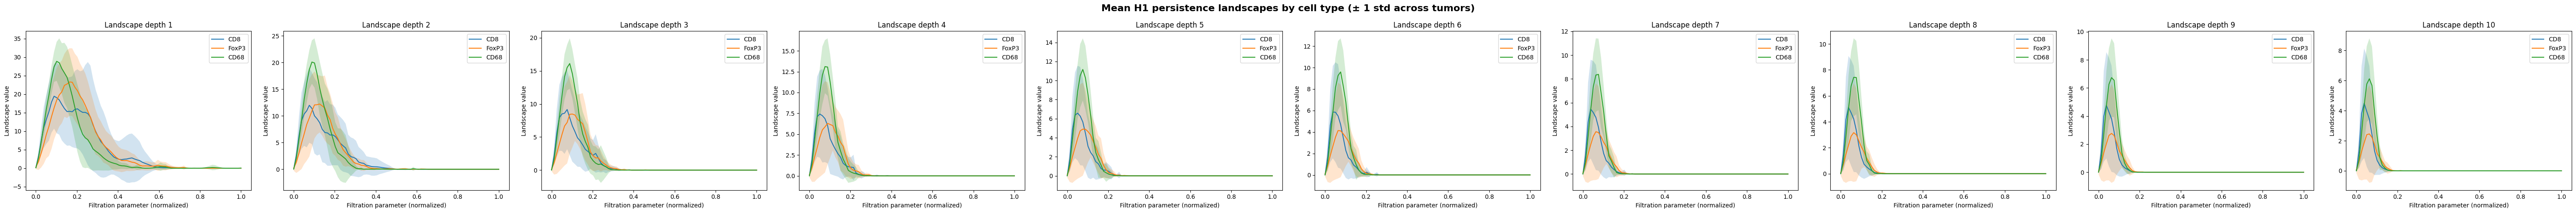

In [ ]:
def mean_landscape_permutation_test(X1, X2, n_permutations=10000, seed=GLOBAL_SEED):
    """
    Two-sample permutation test on mean landscape vectors.
    H0: the two groups have the same mean landscape.
    Test statistic: L2 distance between group means.
    """
    rng      = np.random.default_rng(seed)
    observed = np.linalg.norm(X1.mean(axis=0) - X2.mean(axis=0))
    pooled   = np.vstack([X1, X2])
    n1       = len(X1)

    count = 0
    for _ in range(n_permutations):
        perm = rng.permutation(len(pooled))
        dist = np.linalg.norm(
            pooled[perm[:n1]].mean(axis=0) - pooled[perm[n1:]].mean(axis=0)
        )
        if dist >= observed:
            count += 1

    return observed, count / n_permutations


# ── Fit landscape ─────────────────────────────────────────────────────────────

ls = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
ls.fit([r['diagram_h1'] for r in roi_records])

# ── Compute one landscape vector per region ───────────────────────────────────

X_all  = np.vstack([ls.transform([r['diagram_h1']])[0] for r in roi_records])
y_all  = np.array([r['celltype'] for r in roi_records])
t_all  = np.array([r['tumor_id'] for r in roi_records])

# ── Aggregate to tumor-level mean landscape per cell type ─────────────────────
# This accounts for the repeated measures structure (multiple regions per tumor)

def tumor_mean_landscapes(X, y, tumors, celltype):
    """Return one mean landscape vector per tumor for a given cell type."""
    mask     = y == celltype
    X_ct     = X[mask]
    t_ct     = tumors[mask]
    tumor_ids = np.unique(t_ct)
    return np.vstack([X_ct[t_ct == tid].mean(axis=0) for tid in tumor_ids]), tumor_ids

# ── Pairwise tests ────────────────────────────────────────────────────────────

pairs           = list(combinations(celltypes, 2))
alpha_corrected = 0.05 / len(pairs)

print("Two-sample permutation tests on mean H1 landscape vectors (Bonferroni corrected) at 0.05 level:\n")
for ct1, ct2 in pairs:
    X1, _ = tumor_mean_landscapes(X_all, y_all, t_all, ct1)
    X2, _ = tumor_mean_landscapes(X_all, y_all, t_all, ct2)
    observed, p = mean_landscape_permutation_test(X1, X2)
    significant  = 'Yes' if p < alpha_corrected else 'No'
    print(f"  {ct1} vs {ct2}: L2 distance = {observed:.4f} | p = {p:.4f} | Significant? {significant}")

# ── Plot mean landscapes ──────────────────────────────────────────────────────

n_landscapes = X_all.shape[1] // LANDSCAPE_STEPS
fig, axes = plt.subplots(1, n_landscapes, figsize=(6 * n_landscapes, 5), squeeze=False)
fig.suptitle('Mean H1 persistence landscapes by cell type (± 1 std across tumors)', fontsize=16, fontweight='bold')

xs = np.linspace(0, 1, LANDSCAPE_STEPS)
for k in range(n_landscapes):
    ax = axes[0, k]
    sl = slice(k * LANDSCAPE_STEPS, (k + 1) * LANDSCAPE_STEPS)
    for ct in celltypes:
        X_ct, _ = tumor_mean_landscapes(X_all, y_all, t_all, ct)
        mean_ls = X_ct[:, sl].mean(axis=0)
        std_ls  = X_ct[:, sl].std(axis=0)
        ax.plot(xs, mean_ls, label=ct)
        ax.fill_between(xs, mean_ls - std_ls, mean_ls + std_ls, alpha=0.2)
    ax.set_xlabel('Filtration parameter (normalized)')
    ax.set_ylabel('Landscape value')
    ax.set_title(f'Landscape depth {k + 1}')
    ax.legend()

plt.tight_layout()
plt.show()

## IV - Predicting using the raw points rather than persistence homology

A natural question is: **do we need persistent homology at all?** Perhaps simpler spatial summaries extracted directly from the cell coordinates already capture enough information to distinguish cell types.

We build a 15-dimensional **coordinate feature vector**:
- *Relative spread / anisotropy* (4): std and range of $x$ and $y$
- *Nearest-neighbour distances* (5): mean, std, min, max, median of 1-NN distances — captures local clustering and regularity
- *Pairwise distances* (5): mean, std, median, Q25, Q75 — captures overall relative geometry
- *Convex hull area* (1): relative spatial extent after normalization

Count-dependent features ($n$, area/$n$, $n$/area) are excluded, and the explicit normalization removes absolute size information. These features are therefore **non-topological** summaries of the **relative geometry** of the point cloud.

### IV.1 - Pairwise and three-way classification: coordinates vs landscapes

Both feature sets and classifiers are evaluated on **identical tumor-level splits** for a fair four-way comparison. All features are standardized (train-only `StandardScaler`) before classification.

In [ ]:
from scipy.spatial.distance import pdist
from scipy.spatial import ConvexHull
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# ── Coordinate features ───────────────────────────────────────────────────────

def normalize_point_cloud(pts):
    """Center and scale a point cloud to unit RMS radius."""
    pts = np.asarray(pts, dtype=float)
    if len(pts) == 0:
        return pts.copy()
    centered = pts - pts.mean(axis=0)
    scale    = max(np.sqrt(np.mean(np.sum(centered**2, axis=1))), 1e-12)
    return centered / scale


def extract_coordinate_features(pts):
    """15 spatial statistics from a normalized 2D point cloud."""
    if len(pts) < 4:
        return np.zeros(15)

    x, y    = pts[:, 0], pts[:, 1]
    nn_dists = NearestNeighbors(n_neighbors=2).fit(pts).kneighbors(pts)[0][:, 1]
    pw       = pdist(pts)

    try:
        area = ConvexHull(pts).volume
    except Exception:
        area = 0.0

    return np.array([
        np.std(x), np.std(y), np.ptp(x), np.ptp(y),
        np.mean(nn_dists), np.std(nn_dists), np.min(nn_dists),
        np.max(nn_dists), np.median(nn_dists),
        np.mean(pw), np.std(pw), np.median(pw),
        np.percentile(pw, 25), np.percentile(pw, 75),
        area,
    ])


# ── Build feature matrices ────────────────────────────────────────────────────

X_coord = np.vstack([
    extract_coordinate_features(normalize_point_cloud(r['points']))
    for r in roi_records
])
y_all   = np.array([r['celltype'] for r in roi_records])
grp_all = np.array([r['tumor_id'] for r in roi_records])
X_h1    = np.array([r['diagram_h1'] for r in roi_records], dtype=object)

print(f"Coordinate feature matrix: {X_coord.shape}")

# ── Classifiers ───────────────────────────────────────────────────────────────

classifiers = {
    'LDA'      : LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'LogReg'   : LogisticRegression(max_iter=1000),
    'Boosting' : GradientBoostingClassifier(n_estimators=200, max_depth=3),
}

# ── Evaluation ────────────────────────────────────────────────────────────────

tasks = list(combinations(celltypes, 2)) + [tuple(celltypes)]
rows  = []

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    y_task   = y_all[mask]
    grp_task = grp_all[mask]
    Xc_task  = X_coord[mask]
    Xl_task  = X_h1[mask]

    cv = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))))

    # Collect scores per classifier per feature type
    scores = {
        clf_name: {'coord': [], 'landscape': []}
        for clf_name in classifiers
    }

    for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
        y_train, y_test = y_task[train_idx], y_task[test_idx]

        # Fit landscape once per fold, shared across classifiers
        ls      = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
        Xl_train = ls.fit_transform(Xl_task[train_idx])
        Xl_test  = ls.transform(Xl_task[test_idx])

        scaler_c = StandardScaler().fit(Xc_task[train_idx])
        Xc_train = scaler_c.transform(Xc_task[train_idx])
        Xc_test  = scaler_c.transform(Xc_task[test_idx])

        scaler_l = StandardScaler().fit(Xl_train)
        Xl_train = scaler_l.transform(Xl_train)
        Xl_test  = scaler_l.transform(Xl_test)

        for clf_name, clf in classifiers.items():
            try:
                clf.fit(Xc_train, y_train)
                scores[clf_name]['coord'].append(clf.score(Xc_test, y_test))

                clf.fit(Xl_train, y_train)
                scores[clf_name]['landscape'].append(clf.score(Xl_test, y_test))
            except (LinAlgError, ValueError):
                continue

    # Build row with mean ± std for each classifier and feature type
    row = {'Task': task_label}
    for clf_name in classifiers:
        for feat, key in [('Coord', 'coord'), ('Landscape', 'landscape')]:
            vals = scores[clf_name][key]
            col  = f"{clf_name} {feat}"
            row[col]          = np.mean(vals) if vals else np.nan
            row[col + ' std'] = np.std(vals)  if vals else np.nan

    rows.append(row)

# ── Display ───────────────────────────────────────────────────────────────────

df = pd.DataFrame(rows).set_index('Task')

fmt_cols = {col: '{:.1%}' for col in df.columns}
df.style.format(fmt_cols).set_caption(
    'Coordinate features vs H1 persistence landscapes — LDA, LogReg, GradientBoosting — GroupKFold'
)

Coordinate feature matrix: (1581, 15)


,LDA Coord,LDA Coord std,LDA Landscape,LDA Landscape std,LogReg Coord,LogReg Coord std,LogReg Landscape,LogReg Landscape std,Boosting Coord,Boosting Coord std,Boosting Landscape,Boosting Landscape std
Task,,,,,,,,,,,,
CD8 vs FoxP3,77.1%,12.6%,71.6%,11.8%,89.6%,7.9%,70.2%,11.6%,91.8%,8.3%,76.9%,8.7%
CD8 vs CD68,93.9%,10.2%,63.1%,9.7%,93.5%,9.0%,62.3%,8.0%,94.7%,6.7%,64.6%,8.1%
FoxP3 vs CD68,80.8%,14.5%,75.6%,11.1%,86.2%,10.8%,75.3%,8.2%,93.2%,5.7%,77.8%,11.2%
3-way,78.6%,11.1%,56.2%,9.1%,83.7%,10.6%,53.8%,7.4%,90.7%,6.0%,59.2%,6.3%


In [ ]:
# ── Feature matrices ──────────────────────────────────────────────────────────

X_h0    = np.array([r['diagram_h0'] for r in roi_records], dtype=object)
X_h1    = np.array([r['diagram_h1'] for r in roi_records], dtype=object)
X_coord = np.vstack([
    extract_coordinate_features(normalize_point_cloud(r['points']))
    for r in roi_records
])

tasks = list(combinations(celltypes, 2)) + [tuple(celltypes)]
rows  = []

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    y_task   = y_all[mask]
    grp_task = grp_all[mask]

    X_h0_task   = X_h0[mask]
    X_h1_task   = X_h1[mask]
    Xc_task     = X_coord[mask]

    cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))))
    scores = {'H0+H1': [], 'H0+H1+Coord': []}

    for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
        y_train, y_test = y_task[train_idx], y_task[test_idx]

        # Fit landscapes on train only
        ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
        ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

        Xl_train = np.hstack([
            ls_h0.fit_transform(X_h0_task[train_idx]),
            ls_h1.fit_transform(X_h1_task[train_idx]),
        ])
        Xl_test = np.hstack([
            ls_h0.transform(X_h0_task[test_idx]),
            ls_h1.transform(X_h1_task[test_idx]),
        ])

        # Scale coordinate features
        scaler_c = StandardScaler().fit(Xc_task[train_idx])
        Xc_train = scaler_c.transform(Xc_task[train_idx])
        Xc_test  = scaler_c.transform(Xc_task[test_idx])

        # Scale landscape features
        scaler_l = StandardScaler().fit(Xl_train)
        Xl_train = scaler_l.transform(Xl_train)
        Xl_test  = scaler_l.transform(Xl_test)

        # Combined features
        Xcomb_train = np.hstack([Xl_train, Xc_train])
        Xcomb_test  = np.hstack([Xl_test,  Xc_test])

        try:
            clf_topo = GradientBoostingClassifier(n_estimators=200, max_depth=3)
            clf_topo.fit(Xl_train, y_train)
            scores['H0+H1'].append(clf_topo.score(Xl_test, y_test))

            clf_comb = GradientBoostingClassifier(n_estimators=200, max_depth=3)
            clf_comb.fit(Xcomb_train, y_train)
            scores['H0+H1+Coord'].append(clf_comb.score(Xcomb_test, y_test))
        except (LinAlgError, ValueError):
            continue

    rows.append({
        'Task'              : task_label,
        'H0+H1'             : np.mean(scores['H0+H1'])        if scores['H0+H1']        else np.nan,
        'H0+H1 std'         : np.std(scores['H0+H1'])         if scores['H0+H1']        else np.nan,
        'H0+H1+Coord'       : np.mean(scores['H0+H1+Coord'])  if scores['H0+H1+Coord']  else np.nan,
        'H0+H1+Coord std'   : np.std(scores['H0+H1+Coord'])   if scores['H0+H1+Coord']  else np.nan,
    })

pd.DataFrame(rows).set_index('Task').style.format({
    'H0+H1'          : '{:.1%}',
    'H0+H1 std'      : '{:.1%}',
    'H0+H1+Coord'    : '{:.1%}',
    'H0+H1+Coord std': '{:.1%}',
}).set_caption('Gradient Boosting — H0+H1 landscapes vs H0+H1+Coordinate features — GroupKFold')

,H0+H1,H0+H1 std,H0+H1+Coord,H0+H1+Coord std
Task,,,,
CD8 vs FoxP3,77.9%,8.5%,93.0%,5.9%
CD8 vs CD68,65.4%,8.0%,93.9%,8.8%
FoxP3 vs CD68,76.8%,12.5%,91.9%,6.0%
3-way,59.9%,7.8%,90.2%,6.4%


Across all pairwise and three-way classification tasks considered here, the coordinate-based spatial statistics achieved higher mean accuracies than the one-parameter persistence landscape features. The best-performing coordinate models (Gradient Boosting) reached about 92–95% mean accuracy on the binary tasks and about 91% on the three-way task. The landscape-only models, while clearly above chance (up to ~79% pairwise, ~61% three-way with Boosting on H0+H1), remained substantially lower on the same grouped tumor-level evaluation protocol.

Combining landscape features with coordinate features (H0+H1+Coord) yielded a clear improvement over landscapes alone (e.g., from 60% to 90% on the three-way task), reaching performance comparable to coordinates alone. This suggests that the coordinate features largely subsume the discriminative information captured by the one-parameter persistence landscapes, and that the topological summaries do not contribute substantial complementary signal in this setting.

The interpretation should, however, remain limited to the present setting: this dataset, this ROI construction, these one-parameter topological summaries, and these classifiers under tumor-level `StratifiedGroupKFold` evaluation. The results therefore do not show that persistent homology is generally uninformative, only that in this specific pipeline it did not outperform the coordinate-based descriptors.

This also leaves open the possibility that richer topological representations, such as multiparameter persistence landscapes, could capture complementary structure that is not recovered here. Exploring that question would require a different feature construction and lies beyond the scope of the present notebook.